# TP5 — KNN et Régression Logistique

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42


## Question 1.1 — Implémentation de KNN (k = 3, 5, 7, 9, 11)

In [2]:
datasets = {
    "Iris": load_iris(),
    "Wine": load_wine(),
    "Breast Cancer": load_breast_cancer()
}

ks = [3, 5, 7, 9, 11]

def eval_model(y_true, y_pred, average="macro"):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
    }

results_q11 = []

for name, ds in datasets.items():
    X, y = ds.data, ds.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    for k in ks:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        metrics = eval_model(y_test, y_pred, average="macro")
        results_q11.append({"dataset": name, "k": k, **metrics})

df_q11 = pd.DataFrame(results_q11).sort_values(["dataset", "k"])
df_q11


,dataset,k,accuracy,precision,recall,f1
10,Breast Cancer,3,0.982456,0.986486,0.976190,0.980956
11,Breast Cancer,5,0.956140,0.955062,0.950397,0.952638
12,Breast Cancer,7,0.973684,0.980000,0.964286,0.971277
13,Breast Cancer,9,0.973684,0.980000,0.964286,0.971277
14,Breast Cancer,11,0.973684,0.980000,0.964286,0.971277
0,Iris,3,0.933333,0.944444,0.933333,0.932660
1,Iris,5,0.933333,0.944444,0.933333,0.932660
2,Iris,7,0.966667,0.969697,0.966667,0.966583
3,Iris,9,0.966667,0.969697,0.966667,0.966583
4,Iris,11,0.966667,0.969697,0.966667,0.966583


## Question 1.2 — Métrique de distance (Euclidienne vs Manhattan)

In [3]:
distances = {
    "euclidean": {"metric": "minkowski", "p": 2},
    "manhattan": {"metric": "minkowski", "p": 1},
}

results_q12 = []
for name, ds in datasets.items():
    X, y = ds.data, ds.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    for dist_name, params in distances.items():
        for k in ks:
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("knn", KNeighborsClassifier(n_neighbors=k, **params))
            ])
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            metrics = eval_model(y_test, y_pred, average="macro")
            results_q12.append({"dataset": name, "distance": dist_name, "k": k, **metrics})

df_q12 = pd.DataFrame(results_q12).sort_values(["dataset", "distance", "k"])
df_q12


,dataset,distance,k,accuracy,precision,recall,f1
20,Breast Cancer,euclidean,3,0.982456,0.986486,0.976190,0.980956
21,Breast Cancer,euclidean,5,0.956140,0.955062,0.950397,0.952638
22,Breast Cancer,euclidean,7,0.973684,0.980000,0.964286,0.971277
23,Breast Cancer,euclidean,9,0.973684,0.980000,0.964286,0.971277
24,Breast Cancer,euclidean,11,0.973684,0.980000,0.964286,0.971277
25,Breast Cancer,manhattan,3,0.964912,0.967230,0.957341,0.961911
26,Breast Cancer,manhattan,5,0.964912,0.967230,0.957341,0.961911
27,Breast Cancer,manhattan,7,0.973684,0.980000,0.964286,0.971277
28,Breast Cancer,manhattan,9,0.973684,0.980000,0.964286,0.971277
29,Breast Cancer,manhattan,11,0.973684,0.980000,0.964286,0.971277


## Question 1.4 — Optimisation de k (Accuracy vs k + Validation croisée)

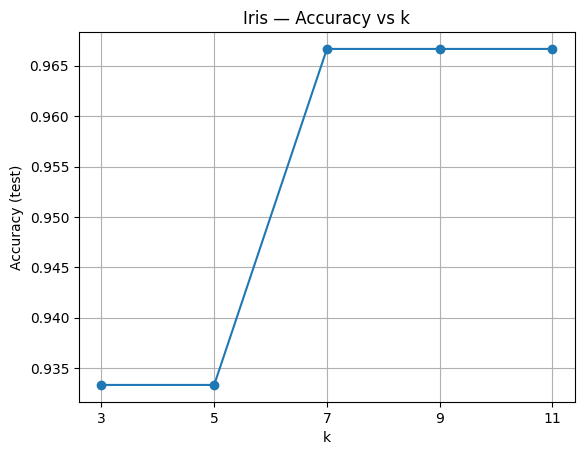

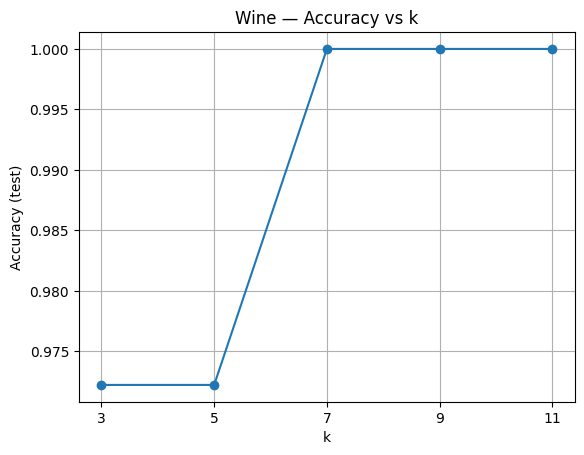

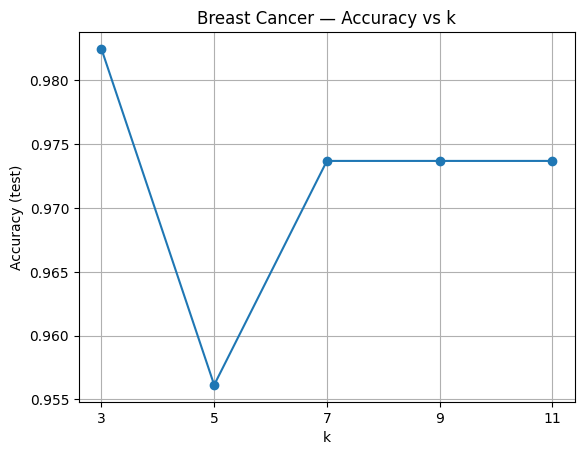

{'Iris': 7, 'Wine': 7, 'Breast Cancer': 3}

In [4]:
# Accuracy vs k (sur le split train/test) + choix du meilleur k (accuracy test)
best_k_test = {}
for name, ds in datasets.items():
    X, y = ds.data, ds.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    accs = []
    for k in ks:
        pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
        pipe.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, pipe.predict(X_test)))
    best_k_test[name] = ks[int(np.argmax(accs))]
    plt.figure()
    plt.plot(ks, accs, marker="o")
    plt.xlabel("k")
    plt.ylabel("Accuracy (test)")
    plt.title(f"{name} — Accuracy vs k")
    plt.xticks(ks)
    plt.grid(True)
    plt.show()

best_k_test


In [5]:
# Validation croisée pour confirmer le choix (accuracy moyenne CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

best_k_cv = {}
cv_table_rows = []

for name, ds in datasets.items():
    X, y = ds.data, ds.target
    mean_scores = []
    std_scores = []
    for k in ks:
        pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
        mean_scores.append(scores.mean())
        std_scores.append(scores.std())
        cv_table_rows.append({"dataset": name, "k": k, "cv_accuracy_mean": scores.mean(), "cv_accuracy_std": scores.std()})
    best_k_cv[name] = ks[int(np.argmax(mean_scores))]

df_cv = pd.DataFrame(cv_table_rows).sort_values(["dataset", "k"])
df_cv, best_k_cv


(          dataset   k  cv_accuracy_mean  cv_accuracy_std
 10  Breast Cancer   3          0.966589         0.017058
 11  Breast Cancer   5          0.963096         0.017886
 12  Breast Cancer   7          0.964866         0.018378
 13  Breast Cancer   9          0.966620         0.016059
 14  Breast Cancer  11          0.963096         0.014028
 0            Iris   3          0.946667         0.054160
 1            Iris   5          0.973333         0.024944
 2            Iris   7          0.960000         0.032660
 3            Iris   9          0.946667         0.033993
 4            Iris  11          0.960000         0.032660
 5            Wine   3          0.966190         0.021091
 6            Wine   5          0.971746         0.018074
 7            Wine   7          0.971905         0.025206
 8            Wine   9          0.971905         0.025206
 9            Wine  11          0.966190         0.033135,
 {'Iris': 5, 'Wine': 7, 'Breast Cancer': 9})

## Question 2.1 — Matrices de confusion (meilleur k)

In [6]:
def best_k_for_dataset(name):
    # prefer CV best k
    return best_k_cv.get(name, best_k_test.get(name, 3))

confusions = {}
for name, ds in datasets.items():
    X, y = ds.data, ds.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    k_best = best_k_for_dataset(name)
    pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k_best))])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    confusions[name] = cm

    print(f"=== {name} | k = {k_best} ===")
    print("Confusion matrix:", cm)
    print()


=== Iris | k = 5 ===
Confusion matrix: [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

=== Wine | k = 7 ===
Confusion matrix: [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]

=== Breast Cancer | k = 9 ===
Confusion matrix: [[39  3]
 [ 0 72]]



## Question 2.2 — Compromis Precision-Recall + F1 (par classe)

In [7]:
for name, ds in datasets.items():
    X, y = ds.data, ds.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    k_best = best_k_for_dataset(name)
    pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k_best))])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    target_names = getattr(ds, "target_names", None)
    print(f"=== {name} | KNN k={k_best} ===")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))
    print()


=== Iris | KNN k=5 ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


=== Wine | KNN k=7 ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


=== Breast Cancer | KNN k=9 ===
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98      

## Question 3.4 — Comparaison globale (tableau + synthèse)

In [8]:
# Tableau récapitulatif: meilleure config KNN (CV) vs Régression Logistique (CV)
summary_rows = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, ds in datasets.items():
    X, y = ds.data, ds.target

    k_best = best_k_for_dataset(name)
    knn_pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k_best))])
    lr_pipe = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=5000))])

    knn_acc = cross_val_score(knn_pipe, X, y, cv=cv, scoring="accuracy")
    lr_acc = cross_val_score(lr_pipe, X, y, cv=cv, scoring="accuracy")

    summary_rows.append({
        "dataset": name,
        "KNN_best_k": k_best,
        "KNN_cv_acc_mean": knn_acc.mean(),
        "KNN_cv_acc_std": knn_acc.std(),
        "LR_cv_acc_mean": lr_acc.mean(),
        "LR_cv_acc_std": lr_acc.std(),
    })

df_summary = pd.DataFrame(summary_rows).sort_values("dataset")
df_summary


,dataset,KNN_best_k,KNN_cv_acc_mean,KNN_cv_acc_std,LR_cv_acc_mean,LR_cv_acc_std
2,Breast Cancer,9,0.966620,0.016059,0.973669,0.016627
0,Iris,5,0.973333,0.024944,0.953333,0.045216
1,Wine,7,0.971905,0.025206,0.983333,0.013608


**Synthèse (très court)**

- KNN: adapté quand la notion de proximité est pertinente, données pas trop grandes, features bien normalisées.
- Limites: coût en prédiction (stockage + calcul distances), sensible au bruit et à l’échelle, curse of dimensionality.
- Améliorations/alternatives: choix de k via CV, pondération par distance, réduction de dimension (PCA), modèles linéaires (RL), SVM, arbres/forêts.


## Partie 4 — Régression Logistique vs KNN (évaluation sur test set)

In [9]:
rows = []
for name, ds in datasets.items():
    X, y = ds.data, ds.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    # KNN best k
    k_best = best_k_for_dataset(name)
    knn_pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k_best))])
    knn_pipe.fit(X_train, y_train)
    knn_pred = knn_pipe.predict(X_test)
    knn_metrics = eval_model(y_test, knn_pred, average="macro")

    # Logistic Regression
    lr_pipe = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=5000))])
    lr_pipe.fit(X_train, y_train)
    lr_pred = lr_pipe.predict(X_test)
    lr_metrics = eval_model(y_test, lr_pred, average="macro")

    rows.append({
        "dataset": name,
        "KNN_k": k_best,
        "KNN_accuracy": knn_metrics["accuracy"],
        "KNN_precision_macro": knn_metrics["precision"],
        "KNN_recall_macro": knn_metrics["recall"],
        "KNN_f1_macro": knn_metrics["f1"],
        "LR_accuracy": lr_metrics["accuracy"],
        "LR_precision_macro": lr_metrics["precision"],
        "LR_recall_macro": lr_metrics["recall"],
        "LR_f1_macro": lr_metrics["f1"],
    })

df_compare = pd.DataFrame(rows).sort_values("dataset")
df_compare


,dataset,KNN_k,KNN_accuracy,KNN_precision_macro,KNN_recall_macro,KNN_f1_macro,LR_accuracy,LR_precision_macro,LR_recall_macro,LR_f1_macro
2,Breast Cancer,9,0.973684,0.980000,0.964286,0.971277,0.982456,0.981151,0.981151,0.981151
0,Iris,5,0.933333,0.944444,0.933333,0.932660,0.933333,0.933333,0.933333,0.933333
1,Wine,7,1.000000,1.000000,1.000000,1.000000,0.972222,0.977778,0.966667,0.970962
